<a href="https://colab.research.google.com/github/ChanggonSong/AI-Study/blob/main/%EC%8B%A4%EC%8A%B53_1_abalone__%EB%B6%84%EB%A5%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [113]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/abalone.data', header=None)

# 칼럼명이 없으므로 추가.
columns = ["Sex", "Length", "Diameter", "Height", "Whole weight", "Shucked weight", "Viscera weight", "Shell weight", "Rings"]
df.columns = columns
df

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [114]:
from sklearn.preprocessing import StandardScaler, LabelEncoder


label = LabelEncoder()
df['Sex'] = label.fit_transform(df['Sex']) # 성별의 M, F, I를 0, 1, 2의 수치형 데이터로 매핑하고 변환된 결과를 'Sex' 열에 다시 할당합니다.
df.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,2,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,2,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,0,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,2,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,1,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [115]:
df.iloc[:,0].value_counts()

2    1528
1    1342
0    1307
Name: Sex, dtype: int64

In [116]:
# 결측치 개수 파악
# 셀 실행 결과를 데이터프레임으로 보고 싶을 때 to_frame()과 pd.DataFrame() 두 가지를 사용 가능
df.isnull().sum().to_frame('nan_count')

,nan_count
Sex,0
Length,0
Diameter,0
Height,0
Whole weight,0
Shucked weight,0
Viscera weight,0
Shell weight,0
Rings,0


In [117]:
# 결측치 비율 파악
pd.DataFrame(data=df.isnull().sum()/len(df),columns=['nan_ratio'])

,nan_ratio
Sex,0.0
Length,0.0
Diameter,0.0
Height,0.0
Whole weight,0.0
Shucked weight,0.0
Viscera weight,0.0
Shell weight,0.0
Rings,0.0


In [118]:
# 결측치가 있는 행을 제거
df = df[~df.isnull().any(axis=1)]

In [119]:
y = df.iloc[:, -1]   # 마지막 열 Rings
y

0       15
1        7
2        9
3       10
4        7
        ..
4172    11
4173    10
4174     9
4175    10
4176    12
Name: Rings, Length: 4177, dtype: int64

In [120]:
# 마지막 열을 y에, 나머지를 X에 저장
X = df.iloc[:, :-1]  # 마지막 열을 제외한 모든 열
X

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight
0,2,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500
1,2,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700
2,0,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100
3,2,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550
4,1,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550
...,...,...,...,...,...,...,...,...
4172,0,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490
4173,2,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605
4174,2,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080
4175,0,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960


In [121]:
abalone_full = X.to_numpy()
print(abalone_full)

[[2.     0.455  0.365  ... 0.2245 0.101  0.15  ]
 [2.     0.35   0.265  ... 0.0995 0.0485 0.07  ]
 [0.     0.53   0.42   ... 0.2565 0.1415 0.21  ]
 ...
 [2.     0.6    0.475  ... 0.5255 0.2875 0.308 ]
 [0.     0.625  0.485  ... 0.531  0.261  0.296 ]
 [2.     0.71   0.555  ... 0.9455 0.3765 0.495 ]]


In [122]:
abalone_target = y.to_numpy()
print(abalone_target)

[15  7  9 ...  9 10 12]


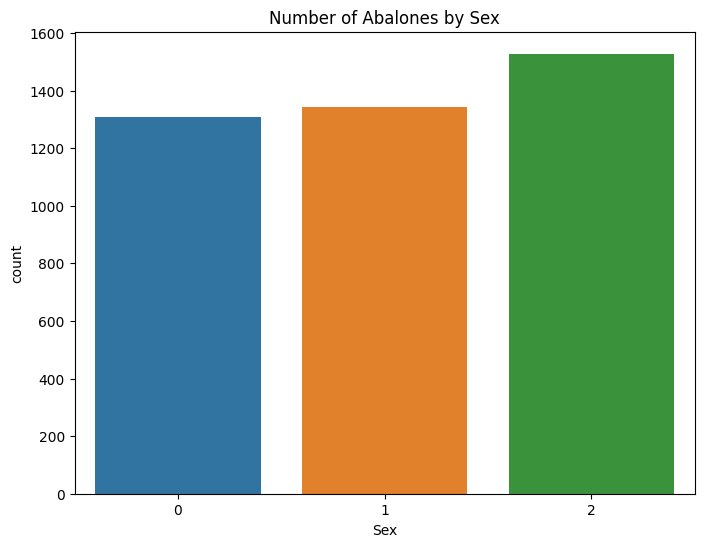

In [123]:
# 성별 레이블별 갯수 및 차트 표시
plt.figure(figsize=(8, 6))
sns.countplot(x='Sex', data=df)
plt.title('Number of Abalones by Sex')
plt.show()

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


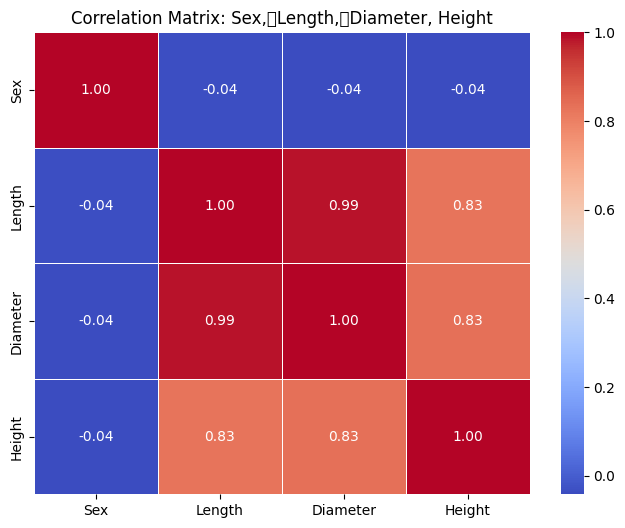

In [124]:
# Sex,	Length,	Diameter, Height 상관관계 분석
correlation_matrix = df[['Sex', 'Length', 'Diameter', 'Height']].corr()

# 히트맵 그리기
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix: Sex,	Length,	Diameter, Height')
plt.show()

In [125]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(abalone_full, abalone_target, test_size=0.25, random_state=0)

In [126]:
df.dtypes

Sex                 int64
Length            float64
Diameter          float64
Height            float64
Whole weight      float64
Shucked weight    float64
Viscera weight    float64
Shell weight      float64
Rings               int64
dtype: object

In [127]:
from sklearn.preprocessing import StandardScaler

# 데이터 표준화
scaler = StandardScaler()
train_scaled = scaler.fit_transform(X_train)
test_scaled = scaler.transform(X_test)

In [128]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [129]:
# SVM
from sklearn.svm import SVC

clf_svm = SVC(random_state=0)
clf_svm.fit(train_scaled, y_train)

pred_svm = clf_svm.predict(test_scaled)

print("\n--- SVM Classifier ---")
print(accuracy_score(y_test, pred_svm))
print(confusion_matrix(y_test, pred_svm))


--- SVM Classifier ---
0.2631578947368421
[[ 0  7  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  3  8  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  7  8 20  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  1  3 21 28  5  4  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  1 15 47 26 21  4  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  4 18 52 53 11  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 11 22 73 43  3  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  1  7 13 51 47 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  6 11 35 45 24  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  2  7 30 39 14  0  0  0  0  1  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  1  3  9 24 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  1 12 15  3  0  0  0  0  1  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  5 14  3  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  1  

In [130]:
# LR

from sklearn.linear_model import LogisticRegression

clf_lr = LogisticRegression(random_state=0)
clf_lr.fit(train_scaled, y_train)

pred_lr = clf_lr.predict(test_scaled)

print ("\n--- Logistic Regression Classifier ---")
print (accuracy_score(y_test, pred_lr))
print (confusion_matrix(y_test, pred_lr))


--- Logistic Regression Classifier ---
0.2545454545454545
[[ 0  6  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  3  8  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  5 10 20  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  2  3 18 29  8  2  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 15 40 45 12  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  5 16 62 45 10  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  2  9 32 66 39  3  0  1  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  1  9 18 44 44 23  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  1  6 12 31 47 21  0  2  0  1  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  1 10 26 28 21  0  3  0  1  3  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  6  4 23 15  0  0  0  2  1  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  1  7 15  4  0  3  0  1  0  1  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  2 11  6  0  2  0  1  0  0  0  0  0  0  0  0  0  0]
 [ 0 

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [131]:
# DT

from sklearn.tree import DecisionTreeClassifier

clf_dt = DecisionTreeClassifier(random_state=0)
clf_dt.fit(train_scaled, y_train)

pred_dt = clf_dt.predict(test_scaled)

print ("\n--- Decision Tree Classifier ---")
print (accuracy_score(y_test, pred_dt))
print (confusion_matrix(y_test, pred_dt))


--- Decision Tree Classifier ---
0.18181818181818182
[[ 1  5  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  4  5  2  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 10  7 11  7  4  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  2  7 12 22 11  2  2  1  2  1  0  0  0  0  0  0  0  0  0  1  0  0  0]
 [ 0  0  4 15 36 33 15  3  4  3  1  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  2  9 26 30 37 15 12  1  4  1  2  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  4 11 28 40 31 13  7  7  1  4  4  2  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  1  8 13 34 25 19 15 11  3  4  4  1  0  1  0  0  0  0  0  0  0]
 [ 0  0  0  1  3 11 21 35 15  9 11  3  1  1  5  5  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  2  9 19 20 11  9  9  3  3  0  0  1  2  1  0  2  2  0  0  0]
 [ 0  0  0  0  0  5  4 10  9  6  6  2  1  2  1  1  2  1  0  0  1  0  0  0]
 [ 0  0  0  0  0  2  3  2  6  5  5  2  1  3  0  0  0  3  0  0  0  0  0  0]
 [ 0  0  0  0  0  1  6  3  2  1  1  4  0  2  1

In [132]:
# RT

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

print ("\n--- Random Forest ---")
rf_clf = RandomForestClassifier(random_state=0)
rf_clf.fit(train_scaled, y_train)
pred = rf_clf.predict(test_scaled)
print(accuracy_score(y_test,pred))
print (confusion_matrix(y_test, pred))


--- Random Forest ---
0.22775119617224882
[[ 0  6  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  5  6  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 10 13 11  5  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  1  8 19 22  9  1  2  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  3 29 31 36  8  5  0  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  3  7 17 51 40 16  3  0  0  2  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  2  8 34 41 45 14  4  3  0  0  0  1  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  3  5 12 38 39 27  6  7  0  0  2  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  4  8 33 38 24  2  8  3  0  1  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  3  5 20 35 13  6  5  2  0  1  1  0  0  0  0  0  1  0  1  0]
 [ 0  0  0  0  1  3  7 11 15  6  4  1  0  0  2  1  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  6 11  7  1  0  3  2  1  1  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  3  4  7  4  2  1  0  0  1  0  0  0  